### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

### Import Datasets

In [5]:
application = pd.read_csv("../Dataset/raw/application_train.csv")
bureau = pd.read_csv("../Dataset/raw/bureau.csv")
bureau_balance = pd.read_csv("../Dataset/raw/bureau_balance.csv")

previous_application = pd.read_csv("../Dataset/raw/previous_application.csv")

installments = pd.read_csv("../Dataset/raw/installments_payments.csv")

credit_card = pd.read_csv("../Dataset/raw/credit_card_balance.csv")

pos_cash = pd.read_csv("../Dataset/raw/POS_CASH_balance.csv")

In [6]:
datasets = {
    "application": application,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments": installments,
    "credit_card": credit_card,
    "pos_cash": pos_cash
}

for name, df in datasets.items():
    print("="*50)
    print(f"{name.upper()}")
    print("="*50)
    print(df.shape)
    print(df.head())
    print("\n")

APPLICATION
(307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE  \
0         351000.0   Unaccompanied 

In [7]:
application.shape, application.SK_ID_CURR.nunique()

((307511, 122), 307511)

In [12]:
def data_quality(df):

    summary = pd.DataFrame()

    summary['column'] = df.columns
    summary['dtype'] = df.dtypes.values
    summary['missing_count'] = df.isnull().sum().values
    summary['missing_pct'] = (df.isnull().mean().values * 100).round(2)

    summary['unique_values'] = df.nunique().values

    return summary.sort_values(by='missing_pct', ascending=False)

In [15]:
dq_application = data_quality(application)

dq_application.head(20)

,column,dtype,missing_count,missing_pct,unique_values
76,COMMONAREA_MEDI,float64,214865,69.87,3202
48,COMMONAREA_AVG,float64,214865,69.87,3181
62,COMMONAREA_MODE,float64,214865,69.87,3128
70,NONLIVINGAPARTMENTS_MODE,float64,213514,69.43,167
56,NONLIVINGAPARTMENTS_AVG,float64,213514,69.43,386
84,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43,214
86,FONDKAPREMONT_MODE,object,210295,68.39,4
68,LIVINGAPARTMENTS_MODE,float64,210199,68.35,736
54,LIVINGAPARTMENTS_AVG,float64,210199,68.35,1868
82,LIVINGAPARTMENTS_MEDI,float64,210199,68.35,1097


In [16]:
application['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

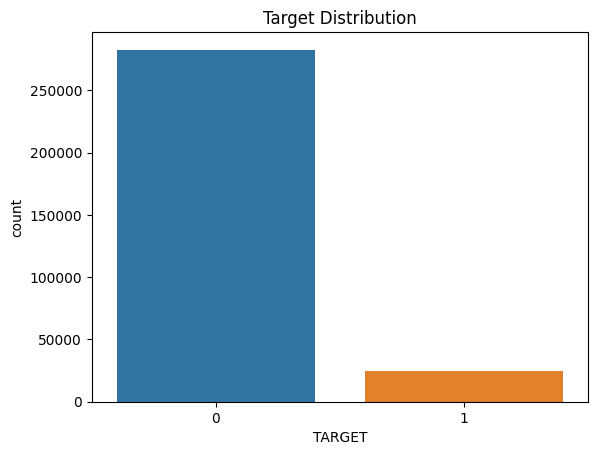

In [17]:
sns.countplot(x='TARGET', data=application)
plt.title("Target Distribution")
plt.show()

In [18]:
bad_rate = application['TARGET'].mean()

print(f"Bad Rate: {bad_rate:.2%}")

Bad Rate: 8.07%


### Missing Values Handling

In [19]:
missing = (
    application.isnull()
    .mean()
    .sort_values(ascending=False)
)

missing.head(30)

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
BASEMENTAREA_MEDI           0.585160
BASEMENTAREA_AVG            0.585160
BASEMENTAREA_MODE           0.585160
EXT_SOURCE_1                0.563811
NONLIVINGAREA_MODE          0.551792
NONLIVINGAREA_AVG           0.551792
NONLIVINGAREA_MEDI          0.551792
E

In [20]:
high_missing_cols = missing[missing > 0.8].index

application_clean = application.drop(columns=high_missing_cols)

print(application.shape)
print(application_clean.shape)

(307511, 122)
(307511, 122)


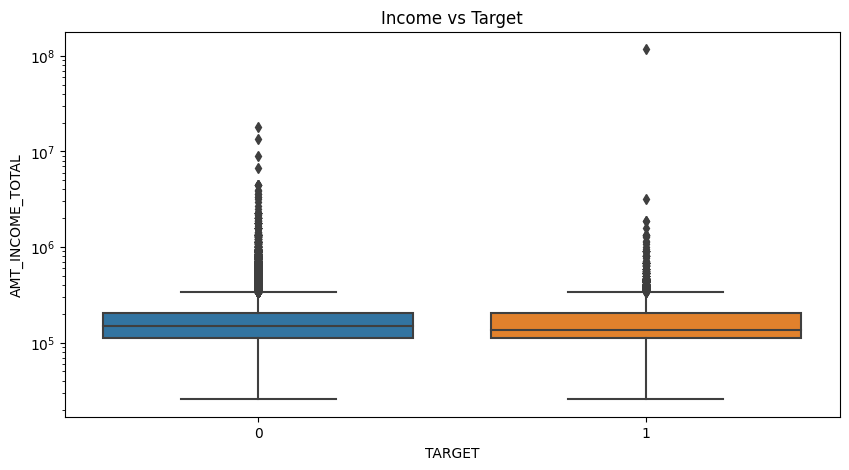

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=application
)

plt.yscale('log')

plt.title("Income vs Target")
plt.show()

### Income Vs Target Comparison

##### Median income is slightly lower for bad customers (`TARGET = 1`), indicating that lower-income borrowers tend to exhibit relatively higher default propensity.

##### A significant overlap exists between good and bad customer distributions, suggesting that income alone cannot be used as a strong standalone predictor of default risk.

##### A large number of extreme outlier observations are present, which may represent data quality issues, high net-worth individuals (HNI), or business owners with unusually high reported income.

##### The variable may require outlier treatment or transformation (e.g., log transformation) before being used in scorecard modeling.

### Some Feature Creation

In [22]:
application_clean['DTI'] = (
    application_clean['AMT_ANNUITY']
    /
    application_clean['AMT_INCOME_TOTAL']
)

application_clean['CREDIT_INCOME_RATIO'] = (
    application_clean['AMT_CREDIT']
    /
    application_clean['AMT_INCOME_TOTAL']
)

application_clean['EMPLOYMENT_YEARS'] = (
    abs(application_clean['DAYS_EMPLOYED']) / 365
)

application_clean['AGE'] = (
    abs(application_clean['DAYS_BIRTH']) / 365
)

### Features Vs Target

In [23]:
application_clean.groupby('TARGET')['DTI'].mean()

TARGET
0    0.180530
1    0.185482
Name: DTI, dtype: float64

In [32]:
application_clean.groupby('TARGET')['CREDIT_INCOME_RATIO'].mean()

TARGET
0    3.963729
1    3.887438
Name: CREDIT_INCOME_RATIO, dtype: float64

In [33]:
application_clean.groupby('TARGET')['AGE'].mean()

TARGET
0    44.214182
1    40.780351
Name: AGE, dtype: float64

In [ ]:
application_clean.groupby('TARGET')['EMPLOYMENT_YEARS'].mean()

TARGET
0    190.873458
1    124.896778
Name: EMPLOYMENT_YEARS, dtype: float64

In [27]:
application_clean['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [28]:
application_clean['DAYS_EMPLOYED'] = (
    application_clean['DAYS_EMPLOYED']
    .replace(365243, np.nan)
)

In [29]:
application_clean['EMPLOYMENT_YEARS'] = (
    abs(application_clean['DAYS_EMPLOYED']) / 365
)
application_clean.groupby('TARGET')['EMPLOYMENT_YEARS'].mean()

TARGET
0    6.679836
1    4.972380
Name: EMPLOYMENT_YEARS, dtype: float64

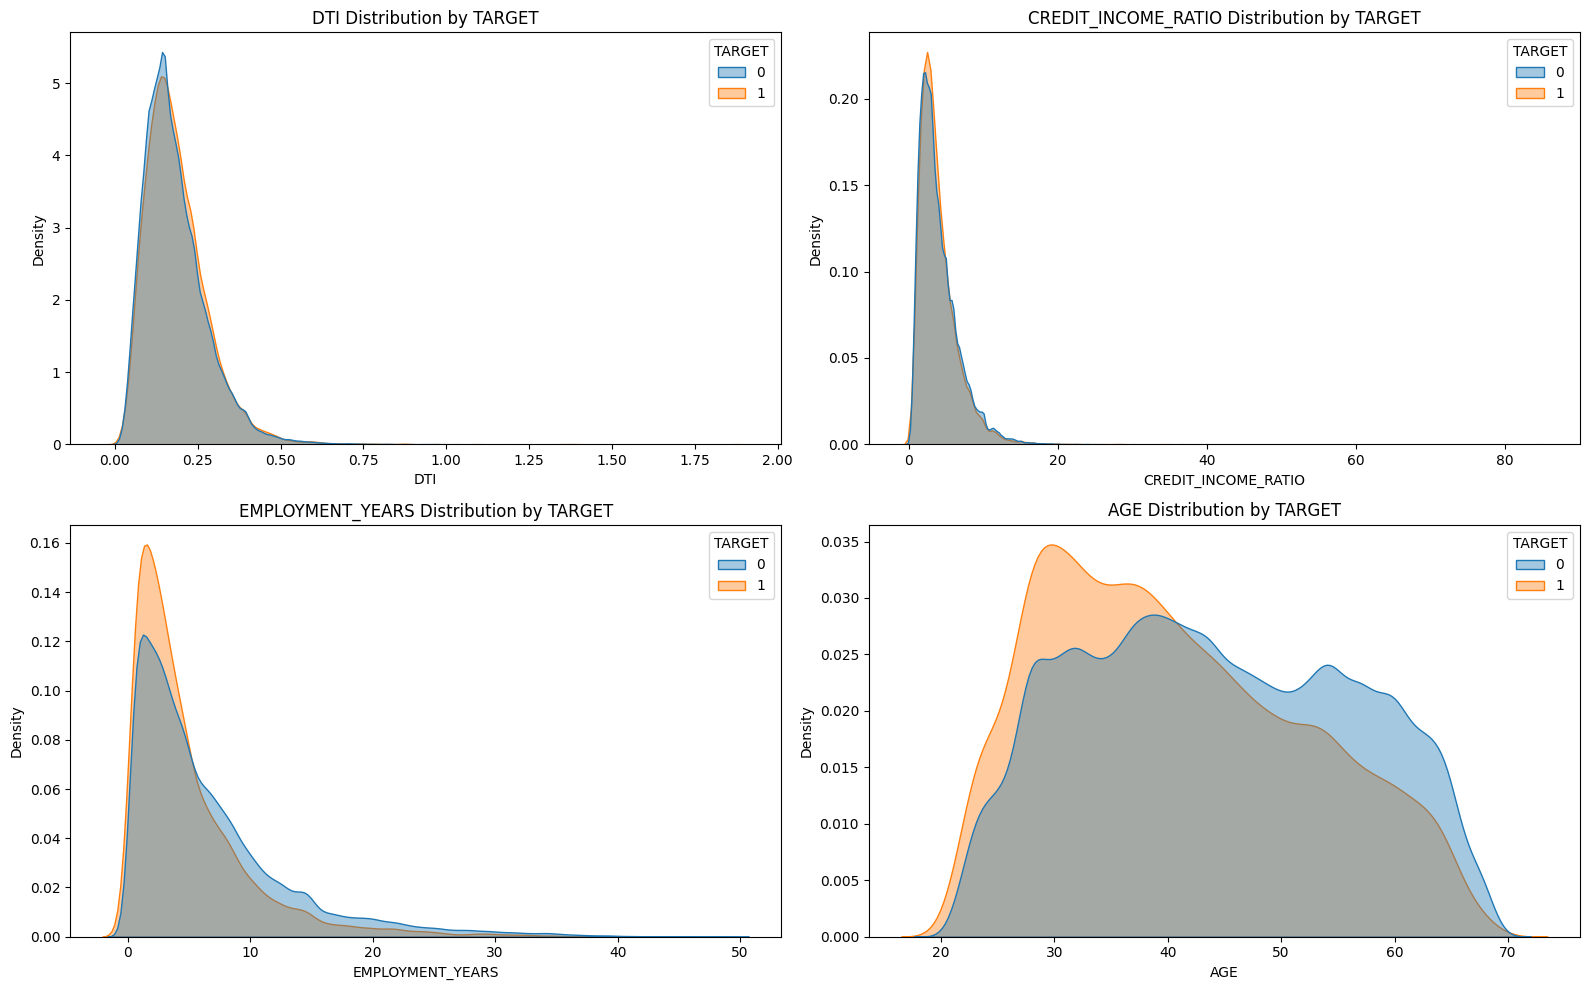

In [30]:
features = [
    'DTI',
    'CREDIT_INCOME_RATIO',
    'EMPLOYMENT_YEARS',
    'AGE'
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16,10)
)

axes = axes.flatten()

for i, col in enumerate(features):

    sns.kdeplot(
        data=application_clean,
        x=col,
        hue='TARGET',
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} Distribution by TARGET')

plt.tight_layout()
plt.show()

#### Inference from KDE Distribution Plots

##### 1. DTI (Debt-to-Income Ratio)
- Bad customers (`TARGET = 1`) show slightly higher DTI values, indicating higher repayment burden relative to income.
- DTI appears to have moderate predictive power and is an important affordability-related risk feature.

---

##### 2. CREDIT_INCOME_RATIO
- Customers with higher loan amount relative to income tend to exhibit higher default propensity.
- The variable is highly right-skewed with outliers, suggesting the need for transformation or capping before modeling.

---

##### 3. EMPLOYMENT_YEARS
- Customers with shorter employment duration tend to have higher risk due to lower employment stability.
- Extremely high values are caused by placeholder records (`365243`) and must be cleaned before modeling.

---

##### 4. AGE
- Younger customers show relatively higher default risk compared to older customers.
- AGE demonstrates clear separation between good and bad customers, making it a strong predictive variable for scorecard modeling.

In [31]:
application_clean.to_csv(
    "../Dataset/Processed/application_clean.csv",
    index=False
)